# Classificação de Gênero Musical com CNN — GTZAN Dataset

Este notebook implementa uma **Convolutional Neural Network (CNN)** para classificação automática de gêneros musicais usando o **GTZAN Dataset**, com os folds de validação cruzada estratificada com filtro de artista propostos por Sturm (2013).

**Referência dos folds:**
> Foleis, J. H., & Tavares, T. F. (2020). *Texture selection for automatic music genre classification*. Applied Soft Computing, 89, 106127.

**Pipeline:**
1. Download dos folds via GitHub
2. Carregamento e pré-processamento dos áudios (Mel-Spectrograma)
3. Definição da arquitetura CNN
4. Treinamento com validação cruzada 3-fold
5. Avaliação e visualização dos resultados

**Gêneros:** blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock

## 1. Instalação de Dependências

In [1]:
# Instalar dependências necessárias
!pip install librosa torch torchvision torchaudio scikit-learn matplotlib seaborn tqdm -q

## 2. Imports e Configurações

In [2]:
# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import urllib.request
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

# Reproducibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

# Info da GPU (se disponível)
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memória: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠ GPU não detectada. Vá em Runtime → Change runtime type → T4 GPU')

# Gêneros do GTZAN
GENRES = ['blues', 'classical', 'country', 'disco',
          'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
GENRE2IDX = {g: i for i, g in enumerate(GENRES)}
IDX2GENRE = {i: g for g, i in GENRE2IDX.items()}
print(f'Gêneros: {GENRES}')


Mounted at /content/drive
Dispositivo: cuda
GPU: Tesla T4
Memória: 15.6 GB
Gêneros: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 3. Download dos Folds (Sturm Filter)

In [3]:
BASE_URL = 'https://raw.githubusercontent.com/julianofoleiss/gtzan_sturm_filter_3folds_stratified/master/'
FOLDS_DIR = Path('gtzan_folds')
FOLDS_DIR.mkdir(exist_ok=True)

fold_files = []
for fold in range(1, 4):
    for split in ['train', 'test', 'evaluate']:
        fname = f'f{fold}_{split}.txt'
        fold_files.append(fname)

print('Baixando arquivos de fold...')
for fname in fold_files:
    dest = FOLDS_DIR / fname
    if not dest.exists():
        url = BASE_URL + fname
        urllib.request.urlretrieve(url, dest)
        print(f'  ✓ {fname}')
    else:
        print(f'  (já existe) {fname}')

print('Download concluído!')

Baixando arquivos de fold...
  ✓ f1_train.txt
  ✓ f1_test.txt
  ✓ f1_evaluate.txt
  ✓ f2_train.txt
  ✓ f2_test.txt
  ✓ f2_evaluate.txt
  ✓ f3_train.txt
  ✓ f3_test.txt
  ✓ f3_evaluate.txt
Download concluído!


## 4. Configuração do Dataset GTZAN

> **Atenção:** Suba a pasta do GTZAN no Google Drive e ajuste o caminho abaixo.
>
> Estrutura esperada no Drive:
> ```
> MyDrive/
>   gtzan/
>     genres_original/        ← GTZAN_ROOT aponta aqui
>       blues/
>         blues.00000.wav
>         ...
>       classical/
>       ...
>     outputs/                ← modelos e gráficos salvos aqui
> ```


In [4]:
# =====================================================
# CONFIGURE O CAMINHO PARA SEU DATASET GTZAN AQUI
# =====================================================
GTZAN_ROOT = Path('/content/drive/MyDrive/genres_original')  # <-- ajuste se necessário

# Pasta onde serão salvos gráficos e modelo
OUTPUT_DIR = Path('/content/drive/MyDrive/gtzan_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR}')
# =====================================================

# Verifica estrutura
if GTZAN_ROOT.exists():
    print(f'✓ Dataset encontrado em: {GTZAN_ROOT}\n')
    for genre in GENRES:
        genre_path = GTZAN_ROOT / genre
        if genre_path.exists():
            n_files = len(list(genre_path.glob('*.wav')))
            print(f'  {genre}: {n_files} arquivos')
        else:
            print(f'  {genre}: *** PASTA NÃO ENCONTRADA ***')
else:
    print(f'⚠ Pasta {GTZAN_ROOT} não encontrada.')
    print('Verifique se o Drive está montado e o caminho GTZAN_ROOT está correto.')


Output dir: /content/drive/MyDrive/gtzan_outputs
✓ Dataset encontrado em: /content/drive/MyDrive/genres_original

  blues: 100 arquivos
  classical: 100 arquivos
  country: 100 arquivos
  disco: 100 arquivos
  hiphop: 100 arquivos
  jazz: 100 arquivos
  metal: 100 arquivos
  pop: 100 arquivos
  reggae: 100 arquivos
  rock: 100 arquivos


## 5. Leitura dos Folds

In [5]:
def parse_fold_file(filepath):
    entries = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            filename = parts[0].lstrip('./')

            if '/' not in filename:
                genre = filename.split('.')[0].split('_')[0]
                filename = f'{genre}/{filename}'

            # Normaliza: troca 'disco_00053.wav' → 'disco.00053.wav'
            folder, fname = filename.split('/', 1)
            fname = fname.replace('_', '.', 1)  # só o primeiro underline
            filename = f'{folder}/{fname}'

            label = parts[1] if len(parts) > 1 else folder
            entries.append((filename, label))
    return entries


def load_folds(folds_dir, n_folds=3):
    """Carrega todos os folds retornando lista de dicts com train/test."""
    folds = []
    for fold_id in range(1, n_folds + 1):
        train_entries = parse_fold_file(folds_dir / f'f{fold_id}_train.txt')
        test_entries  = parse_fold_file(folds_dir / f'f{fold_id}_evaluate.txt')
        folds.append({'fold': fold_id, 'train': train_entries, 'test': test_entries})
        print(f'Fold {fold_id}: {len(train_entries)} treino | {len(test_entries)} teste')
    return folds


folds = load_folds(FOLDS_DIR)

# Distribuição de gêneros no fold 1 (treino)
labels = [e[1] for e in folds[0]['train']]
label_counts = Counter(labels)
print('\nDistribuição no treino do fold 1:')
for genre in GENRES:
    print(f'  {genre:12s}: {label_counts.get(genre, 0)}')

Fold 1: 633 treino | 315 teste
Fold 2: 632 treino | 316 teste
Fold 3: 631 treino | 317 teste

Distribuição no treino do fold 1:
  blues       : 68
  classical   : 66
  country     : 66
  disco       : 63
  hiphop      : 65
  jazz        : 58
  metal       : 61
  pop         : 60
  reggae      : 59
  rock        : 67


## 6. Extração de Features: Mel-Espectrograma

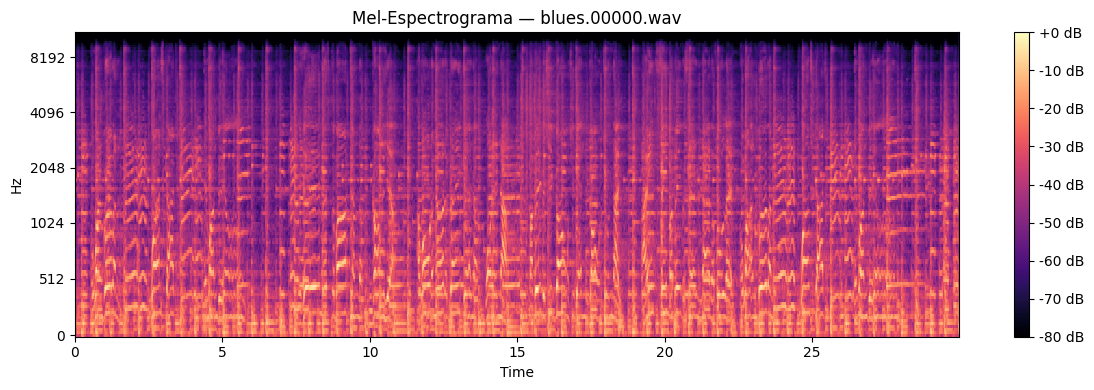

Shape do Mel-Espectrograma: (128, 1292)  (n_mels x frames)


In [6]:
# Parâmetros de áudio e espectrograma
SAMPLE_RATE  = 22050
DURATION     = 30
N_MELS       = 128
N_FFT        = 2048
HOP_LENGTH   = 512
FIXED_FRAMES = 1292

# Cache de mel-spectrogramas pré-extraídos
MEL_CACHE = Path('/content/mel_cache')
MEL_CACHE.mkdir(exist_ok=True)


def load_melspectrogram(filepath, sr=SAMPLE_RATE, duration=DURATION,
                        n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Carrega áudio e extrai Mel-Espectrograma (dB). Tolerante a arquivos corrompidos."""
    try:
        y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
    except Exception:
        y = np.zeros(int(sr * duration))
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                          n_fft=n_fft, hop_length=hop_length)
    return librosa.power_to_db(mel, ref=np.max)


# Exemplo de visualização
if GTZAN_ROOT.exists():
    sample_file = GTZAN_ROOT / 'blues' / 'blues.00000.wav'
    if sample_file.exists():
        mel = load_melspectrogram(sample_file)
        fig, ax = plt.subplots(figsize=(12, 4))
        img = librosa.display.specshow(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                                       x_axis='time', y_axis='mel', ax=ax, cmap='magma')
        fig.colorbar(img, ax=ax, format='%+2.0f dB')
        ax.set_title('Mel-Espectrograma — blues.00000.wav')
        plt.tight_layout()
        plt.show()
        print(f'Shape: {mel.shape}  (n_mels x frames)')
    else:
        print('Arquivo de exemplo não encontrado.')


## 7. Dataset e DataLoader

In [7]:
import torchaudio.transforms as AT
import warnings
warnings.filterwarnings('ignore')


class GTZANDataset(Dataset):
    """
    Dataset PyTorch para o GTZAN.
    Lê mel-spectrogramas pré-extraídos (.npy) do cache.
    Aplica SpecAugment no treino (augment=True).
    """

    def __init__(self, entries, mel_cache, augment=False, fixed_frames=FIXED_FRAMES):
        self.entries      = entries
        self.mel_cache    = Path(mel_cache)
        self.augment      = augment
        self.fixed_frames = fixed_frames
        # SpecAugment calibrado: nem fraco demais (v2) nem forte demais (v3)
        self.freq_mask = AT.FrequencyMasking(freq_mask_param=20)  # v2=20, v3=30
        self.time_mask = AT.TimeMasking(time_mask_param=30)       # v2=30, v3=50

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        rel_path, label_str = self.entries[idx]
        parts    = Path(rel_path)
        npy_path = self.mel_cache / parts.parent / (parts.stem + '.npy')
        mel      = np.load(npy_path)

        if mel.shape[1] < self.fixed_frames:
            mel = np.pad(mel, ((0, 0), (0, self.fixed_frames - mel.shape[1])),
                         mode='constant', constant_values=mel.min())
        else:
            mel = mel[:, :self.fixed_frames]

        mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)

        if self.augment:
            mel_tensor = self.freq_mask(mel_tensor)
            mel_tensor = self.time_mask(mel_tensor)

        label = torch.tensor(GENRE2IDX[label_str], dtype=torch.long)
        return mel_tensor, label


def get_dataloaders(fold_data, mel_cache, batch_size=64):
    """Cria DataLoaders de treino (com SpecAugment) e teste para um fold."""
    train_ds = GTZANDataset(fold_data['train'], mel_cache, augment=True)
    test_ds  = GTZANDataset(fold_data['test'],  mel_cache, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               num_workers=2, pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                               num_workers=2, pin_memory=True, persistent_workers=True)
    return train_loader, test_loader


print('GTZANDataset (cache + SpecAugment) e get_dataloaders definidos.')


Classes GTZANDataset e get_dataloaders definidas.


## 8. Arquitetura da CNN

In [8]:
class MusicGenreCNN(nn.Module):
    """
    CNN para classificação de gênero musical a partir de Mel-Espectrogramas.

    Dropout calibrado entre v2 (underfitting leve) e v3 (overfitting):
    - Blocos conv: 0.3  (igual à v2 — não regularizar demais as features)
    - Classifier fc1: 0.55 (entre 0.5 da v2 e 0.6 da v3)
    - Classifier fc2: 0.35 (entre 0.3 da v2 e 0.4 da v3)
    """

    def __init__(self, n_classes=10, dropout=0.3):
        super(MusicGenreCNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),
            nn.Dropout2d(dropout)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),
            nn.Dropout2d(dropout)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),
            nn.Dropout2d(dropout)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Dropout2d(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.55),  # intermediário: v2=0.5, v3=0.6
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.35),  # intermediário: v2=0.3, v3=0.4
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.classifier(x)


model = MusicGenreCNN(n_classes=len(GENRES)).to(DEVICE)
print(model)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParâmetros totais:     {total_params:,}')
print(f'Parâmetros treináveis: {trainable_params:,}')


MusicGenreCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 4), stride=(2, 4), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.3, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 4), stride=(2, 4), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.3, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 4), stride=(2, 4), padding=0, dilation=1, ceil_mode=False)


## 9. Funções de Treino e Avaliação

In [9]:
def train_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    """Treina o modelo por uma época. scheduler opcional para OneCycleLR."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in tqdm(loader, desc='Treino', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()  # OneCycleLR: step por batch
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += inputs.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    """Avalia o modelo em um conjunto de dados."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Avaliação', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += inputs.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


print('Funções de treino e avaliação definidas.')


Funções de treino e avaliação definidas.


In [10]:
!apt-get install -y ffmpeg -q

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


In [11]:
# load_melspectrogram já definida na célula 6 com tratamento de erros.
print('✓ load_melspectrogram OK.')


In [12]:
import shutil, os

# 1. Copia dataset do Drive para disco local
LOCAL_DATA = Path('/content/genres_original')
if not LOCAL_DATA.exists():
    print('Copiando dataset do Drive para disco local...')
    shutil.copytree(GTZAN_ROOT, LOCAL_DATA)
    print('✓ Cópia concluída!')
else:
    print('✓ Dataset já está no disco local.')
GTZAN_ROOT = LOCAL_DATA

# 2. Pré-extrai mel-spectrogramas para .npy (roda UMA VEZ por sessão)
print('\nVerificando cache de mel-spectrogramas...')
cached, skipped = 0, 0
for genre in GENRES:
    genre_cache = MEL_CACHE / genre
    genre_cache.mkdir(exist_ok=True)
    for wav_path in sorted((GTZAN_ROOT / genre).glob('*.wav')):
        npy_path = genre_cache / (wav_path.stem + '.npy')
        if not npy_path.exists():
            np.save(npy_path, load_melspectrogram(str(wav_path)))
            cached += 1
        else:
            skipped += 1
print(f'✓ Cache: {cached} novos, {skipped} já existiam.')

# 3. Remove checkpoints antigos para forçar novo treino
print('\nLimpando checkpoints antigos...')
for i in range(1, 4):
    ck = OUTPUT_DIR / f'checkpoint_fold{i}.pth'
    if ck.exists():
        os.remove(ck)
        print(f'  Removido: {ck}')
print('✓ Pronto para treinar.')


Copiando...
✓ Concluído!


## 10. Loop de Treinamento com Validação Cruzada 3-Fold

In [13]:
EPOCHS       = 100
BATCH_SIZE   = 64
LR           = 1e-3
WEIGHT_DECAY = 1e-4   # volta para 1e-4 (v3 tinha 1e-3, regularizou demais)
PATIENCE     = 15     # early stopping

fold_histories = []
fold_results   = []

for fold_data in folds:
    fold_id = fold_data['fold']

    checkpoint_path = OUTPUT_DIR / f'checkpoint_fold{fold_id}.pth'
    if checkpoint_path.exists():
        print(f'✓ Fold {fold_id} já concluído, carregando checkpoint...')
        ck = torch.load(checkpoint_path, map_location=DEVICE)
        fold_results.append(ck['result'])
        fold_histories.append(ck['history'])
        continue

    print(f'\n{"="*60}')
    print(f'  FOLD {fold_id}/3')
    print(f'{"="*60}')

    train_loader, test_loader = get_dataloaders(
        fold_data, MEL_CACHE, batch_size=BATCH_SIZE
    )

    model     = MusicGenreCNN(n_classes=len(GENRES)).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # OneCycleLR: warm-up nas primeiras 30% das épocas + cosine decay
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=1e-3,
        epochs=EPOCHS,
        steps_per_epoch=len(train_loader),
        pct_start=0.3,
        div_factor=25,
        final_div_factor=1e4
    )

    history  = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_acc = 0.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, DEVICE, scheduler
        )
        test_loss, test_acc, preds, labels_true = eval_epoch(
            model, test_loader, criterion, DEVICE
        )

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        if test_acc > best_acc:
            best_acc   = test_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_preds  = preds
            best_labels = labels_true
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f'  Early stopping na época {epoch} (melhor: {best_acc:.4f})')
                break

        if epoch % 10 == 0:
            print(f'  Época {epoch:3d}/{EPOCHS} | '
                  f'Treino: loss={train_loss:.4f} acc={train_acc:.4f} | '
                  f'Teste:  loss={test_loss:.4f} acc={test_acc:.4f}')

    result = {
        'fold':     fold_id,
        'best_acc': best_acc,
        'preds':    best_preds,
        'labels':   best_labels,
        'f1_macro': f1_score(best_labels, best_preds, average='macro')
    }

    torch.save({'model_state': best_state, 'result': result, 'history': history},
               checkpoint_path)
    print(f'  ✓ Fold {fold_id} — Melhor acc: {best_acc:.4f} | Checkpoint salvo.')

    fold_results.append(result)
    fold_histories.append(history)

print(f'\n{"="*60}')
print('  RESUMO DA VALIDAÇÃO CRUZADA')
print(f'{"="*60}')
accs = [r['best_acc'] for r in fold_results]
f1s  = [r['f1_macro'] for r in fold_results]
for r in fold_results:
    print(f'  Fold {r["fold"]}: Acc={r["best_acc"]:.4f}  F1-macro={r["f1_macro"]:.4f}')
print(f'  Média Acc: {np.mean(accs):.4f} ± {np.std(accs):.4f}')
print(f'  Média F1:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}')



  FOLD 1/3


Treino:  20%|██        | 2/10 [00:12<00:43,  5.39s/it]/tmp/ipykernel_4900/1566092070.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  Época   1/24 | Treino: loss=2.3444 acc=0.1153 | Teste: loss=2.3209 acc=0.0952


Treino:  60%|██████    | 6/10 [00:25<00:14,  3.58s/it]/tmp/ipykernel_4900/1566092070.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  Época   2/24 | Treino: loss=2.2746 acc=0.1801 | Teste: loss=2.5523 acc=0.0952


...

  Época  22/24 | Treino: loss=1.6438 acc=0.4612 | Teste: loss=1.7261 acc=0.4132


Treino:   0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_4900/1566092070.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  Época  23/24 | Treino: loss=1.6623 acc=0.4612 | Teste: loss=1.7145 acc=0.4227


Treino:  80%|████████  | 8/10 [00:31<00:06,  3.23s/it]/tmp/ipykernel_4900/1566092070.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr, mono=True, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
                                                        

  Época  24/24 | Treino: loss=1.6729 acc=0.4865 | Teste: loss=1.7175 acc=0.4164

  ✓ Melhor acurácia no fold 3: 0.4322

  RESUMO DA VALIDAÇÃO CRUZADA
  Fold 1: Acc=0.4730  F1-macro=0.4077
  Fold 2: Acc=0.4842  F1-macro=0.4778
  Fold 3: Acc=0.4322  F1-macro=0.3926
  Média Acc: 0.4631 ± 0.0224
  Média F1:  0.4260 ± 0.0371


## 11. Visualização: Curvas de Treino

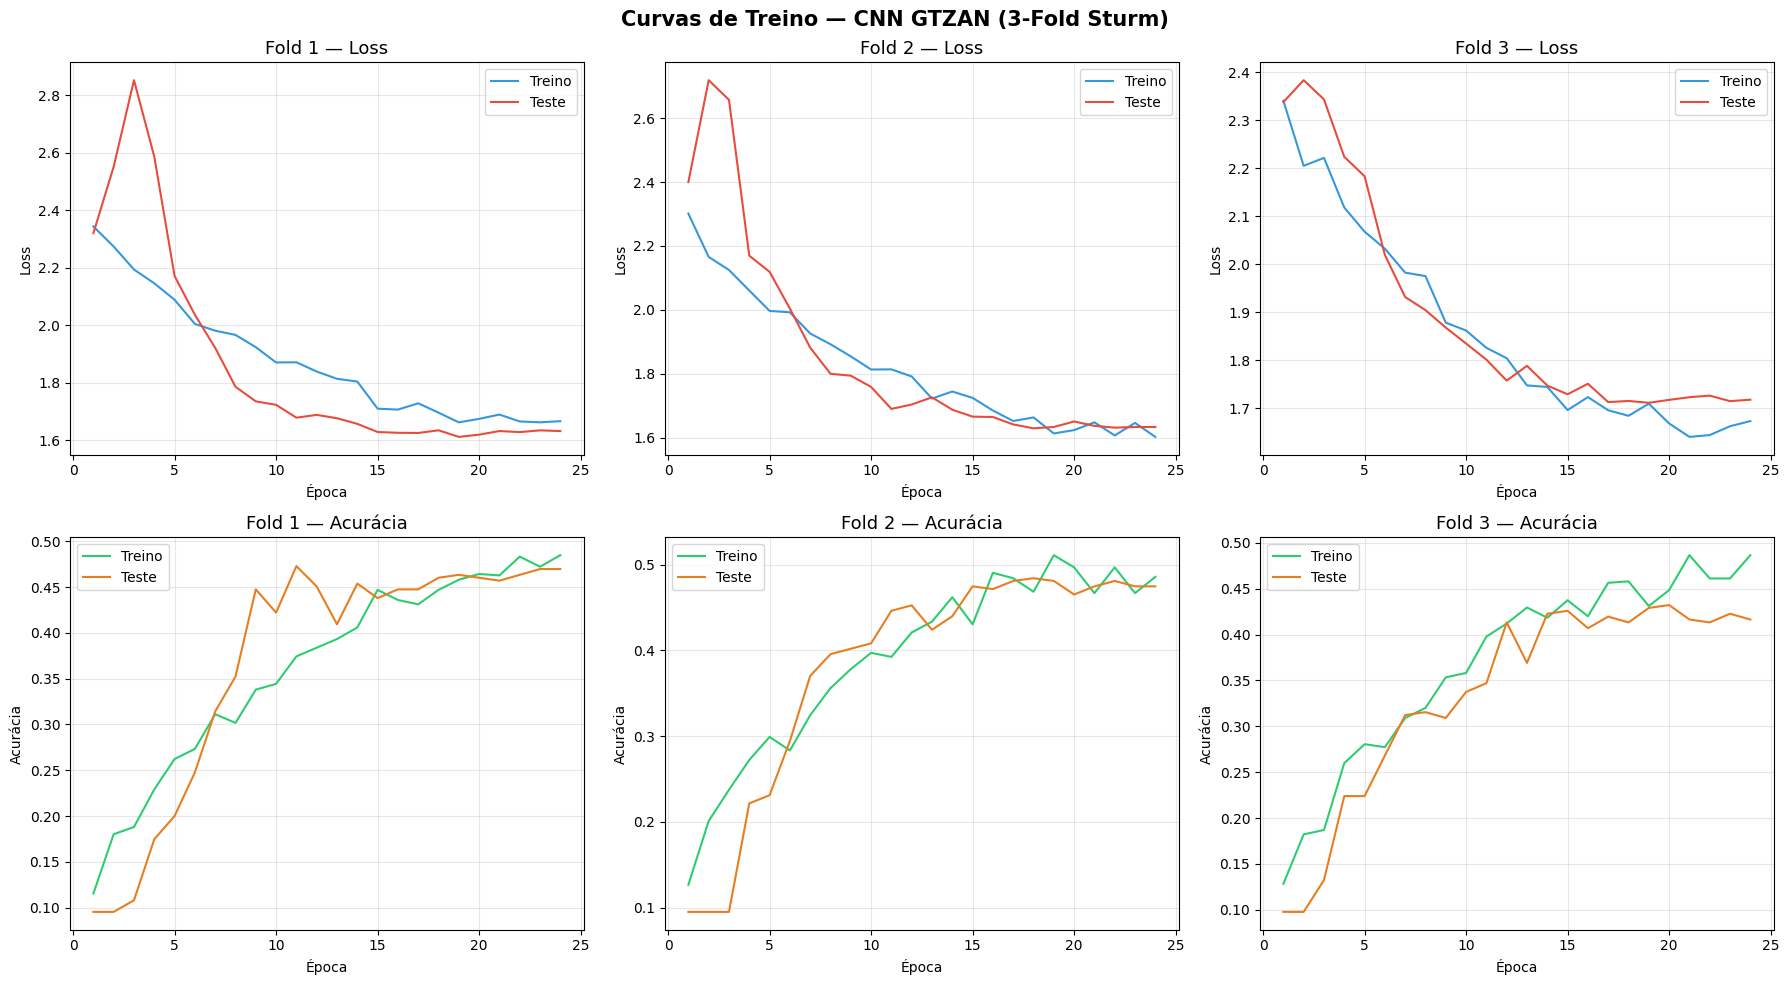

✓ Salvo em: /content/drive/MyDrive/gtzan_outputs/training_curves.png


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (history, ax_loss, ax_acc) in enumerate(
    zip(fold_histories, axes[0], axes[1])
):
    fold_id = i + 1
    epochs = range(1, len(history['train_loss']) + 1)

    ax_loss.plot(epochs, history['train_loss'], label='Treino', color='#3498db')
    ax_loss.plot(epochs, history['test_loss'],  label='Teste',  color='#e74c3c')
    ax_loss.set_title(f'Fold {fold_id} — Loss', fontsize=13)
    ax_loss.set_xlabel('Época')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.plot(epochs, history['train_acc'], label='Treino', color='#2ecc71')
    ax_acc.plot(epochs, history['test_acc'],  label='Teste',  color='#e67e22')
    ax_acc.set_title(f'Fold {fold_id} — Acurácia', fontsize=13)
    ax_acc.set_xlabel('Época')
    ax_acc.set_ylabel('Acurácia')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

plt.suptitle('Curvas de Treino — CNN GTZAN (3-Fold Sturm)', fontsize=15, fontweight='bold')
plt.tight_layout()
out_path = OUTPUT_DIR / 'training_curves.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Salvo em: {out_path}')


## 12. Visualização: Matriz de Confusão (Melhor Fold)

Visualizando o fold 2 (melhor acurácia: 0.4842)


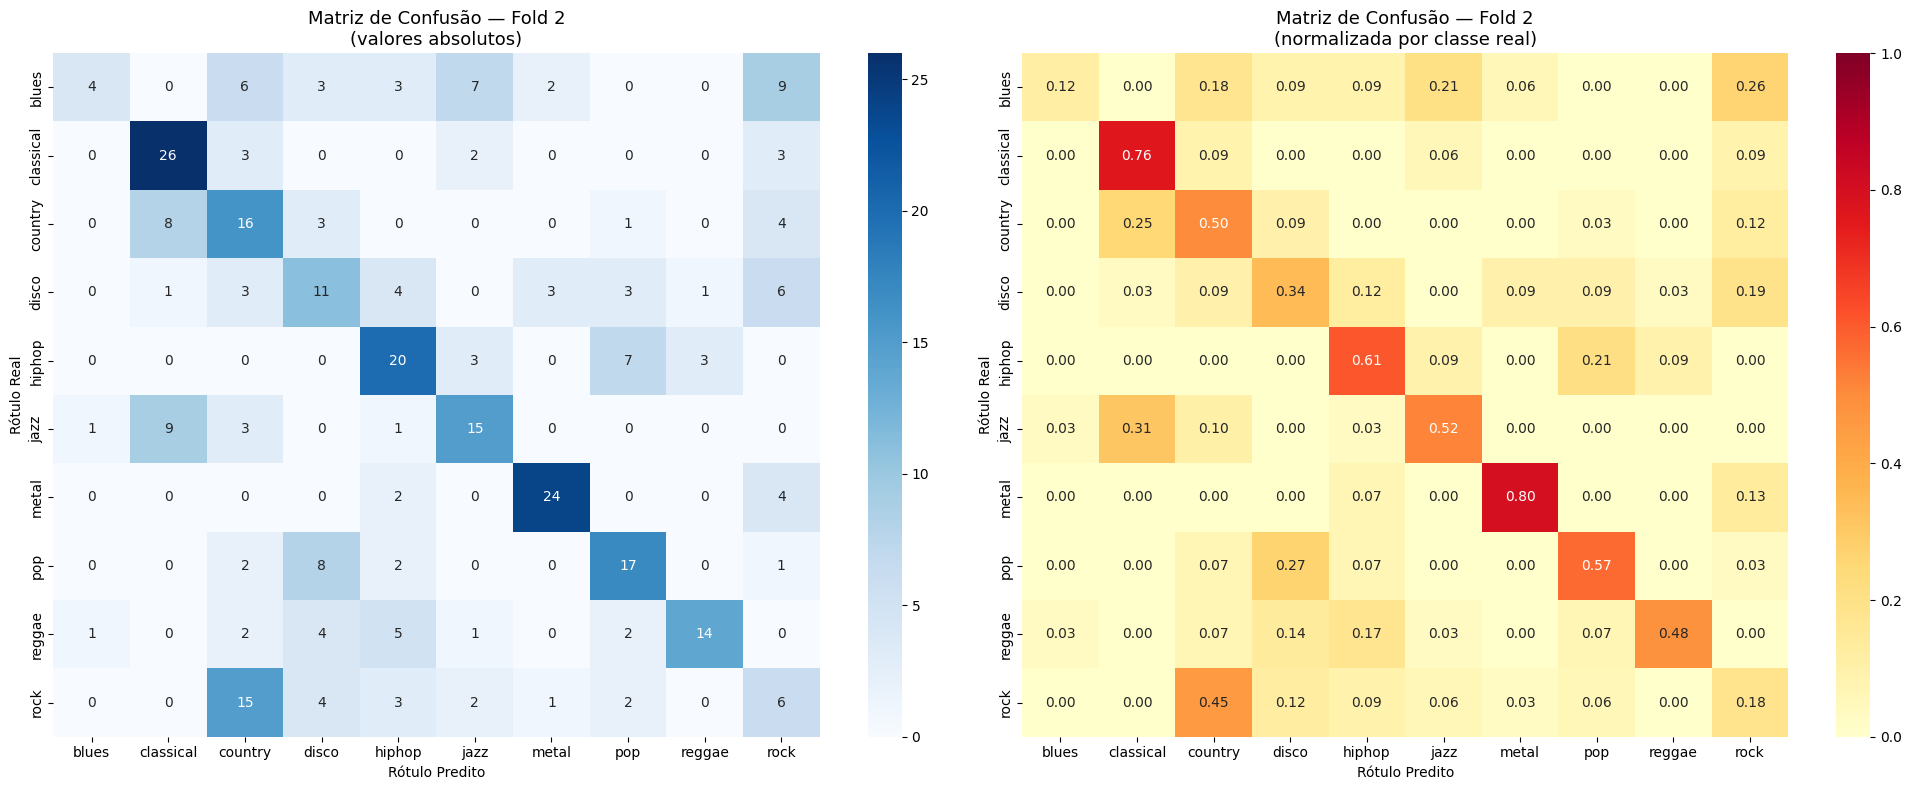

✓ Salvo em: /content/drive/MyDrive/gtzan_outputs/confusion_matrix.png


In [15]:
# Escolhe o fold com maior acurácia
best_fold = max(fold_results, key=lambda x: x['best_acc'])
print(f"Visualizando o fold {best_fold['fold']} (melhor acurácia: {best_fold['best_acc']:.4f})")

cm = confusion_matrix(best_fold['labels'], best_fold['preds'])
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matriz absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES, ax=axes[0])
axes[0].set_title(f'Matriz de Confusão — Fold {best_fold["fold"]}\n(valores absolutos)',
                  fontsize=13)
axes[0].set_ylabel('Rótulo Real')
axes[0].set_xlabel('Rótulo Predito')

# Matriz normalizada
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=GENRES, yticklabels=GENRES, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title(f'Matriz de Confusão — Fold {best_fold["fold"]}\n(normalizada por classe real)',
                  fontsize=13)
axes[1].set_ylabel('Rótulo Real')
axes[1].set_xlabel('Rótulo Predito')

plt.tight_layout()
out_path = OUTPUT_DIR / 'confusion_matrix.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Salvo em: {out_path}')


## 13. Relatório de Classificação

In [16]:
print(f"{'='*60}")
print(f"  RELATÓRIO DE CLASSIFICAÇÃO — Fold {best_fold['fold']}")
print(f"{'='*60}")
print(classification_report(
    best_fold['labels'], best_fold['preds'],
    target_names=GENRES, digits=4
))

# Tabela resumo de todos os folds
print('\nResumo por fold:')
df_results = pd.DataFrame([{
    'Fold': r['fold'],
    'Acurácia': f"{r['best_acc']:.4f}",
    'F1-Macro': f"{r['f1_macro']:.4f}"
} for r in fold_results])
df_results.loc[len(df_results)] = [
    'Média ± DP',
    f"{np.mean(accs):.4f} ± {np.std(accs):.4f}",
    f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}"
]
print(df_results.to_string(index=False))

  RELATÓRIO DE CLASSIFICAÇÃO — Fold 2
              precision    recall  f1-score   support

       blues     0.6667    0.1176    0.2000        34
   classical     0.5909    0.7647    0.6667        34
     country     0.3200    0.5000    0.3902        32
       disco     0.3333    0.3438    0.3385        32
      hiphop     0.5000    0.6061    0.5479        33
        jazz     0.5000    0.5172    0.5085        29
       metal     0.8000    0.8000    0.8000        30
         pop     0.5312    0.5667    0.5484        30
      reggae     0.7778    0.4828    0.5957        29
        rock     0.1818    0.1818    0.1818        33

    accuracy                         0.4842       316
   macro avg     0.5202    0.4881    0.4778       316
weighted avg     0.5163    0.4842    0.4726       316


Resumo por fold:
      Fold        Acurácia        F1-Macro
         1          0.4730          0.4077
         2          0.4842          0.4778
         3          0.4322          0.3926
Média ± DP 0.

## 14. Salvando o Modelo do Melhor Fold

In [17]:
# Retreina o melhor fold para salvar o modelo final
best_fold_id   = best_fold['fold'] - 1
best_fold_data = folds[best_fold_id]

train_loader, _ = get_dataloaders(best_fold_data, MEL_CACHE, batch_size=BATCH_SIZE)

final_model     = MusicGenreCNN(n_classes=len(GENRES)).to(DEVICE)
final_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
final_optimizer = optim.AdamW(final_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
final_scheduler = optim.lr_scheduler.OneCycleLR(
    final_optimizer,
    max_lr=1e-3,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,
    div_factor=25,
    final_div_factor=1e4
)

print(f'Treinando modelo final (Fold {best_fold["fold"]}, {EPOCHS} épocas)...')
for epoch in range(1, EPOCHS + 1):
    loss, acc = train_epoch(final_model, train_loader, final_criterion,
                            final_optimizer, DEVICE, final_scheduler)
    if epoch % 10 == 0:
        print(f'  Época {epoch}/{EPOCHS} — Loss: {loss:.4f}  Acc: {acc:.4f}')

checkpoint = {
    'model_state': final_model.state_dict(),
    'genres':      GENRES,
    'genre2idx':   GENRE2IDX,
    'best_fold':   best_fold['fold'],
    'best_acc':    best_fold['best_acc'],
    'hyperparams': {
        'n_mels': N_MELS, 'n_fft': N_FFT, 'hop_length': HOP_LENGTH,
        'sample_rate': SAMPLE_RATE, 'duration': DURATION,
        'fixed_frames': FIXED_FRAMES
    }
}
model_path = OUTPUT_DIR / 'gtzan_cnn_best.pth'
torch.save(checkpoint, model_path)
print(f'\n✓ Modelo salvo em: {model_path}')


Treinando modelo final (Fold 2)...


  Época 10/24 — Loss: 1.8871  Acc: 0.3797


  Época 20/24 — Loss: 1.6481  Acc: 0.4810



✓ Modelo salvo em: /content/drive/MyDrive/gtzan_outputs/gtzan_cnn_best.pth


## 15. Inferência: Classificando uma Nova Música

In [18]:
def predict_genre(audio_path, model, device=DEVICE):
    """
    Prediz o gênero musical de um arquivo de áudio.
    Retorna: (gênero predito, dicionário de probabilidades)
    """
    mel = load_melspectrogram(audio_path)

    # Ajusta frames
    if mel.shape[1] < FIXED_FRAMES:
        mel = np.pad(mel, ((0, 0), (0, FIXED_FRAMES - mel.shape[1])),
                     mode='constant', constant_values=mel.min())
    else:
        mel = mel[:, :FIXED_FRAMES]

    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
    x = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1).squeeze().cpu().numpy()

    predicted_genre = GENRES[np.argmax(probs)]
    prob_dict = {genre: float(probs[i]) for i, genre in enumerate(GENRES)}

    return predicted_genre, prob_dict


# Exemplo de uso
# predicted, probs = predict_genre('caminho/para/musica.wav', final_model)
# print(f'Gênero predito: {predicted}')
# print('Probabilidades:')
# for genre, prob in sorted(probs.items(), key=lambda x: -x[1]):
#     bar = '█' * int(prob * 30)
#     print(f'  {genre:12s} {bar} {prob:.3f}')

print('Função predict_genre() definida e pronta para uso.')
print("Descomente as linhas acima e forneça um caminho de áudio para testar.")

Função predict_genre() definida e pronta para uso.
Descomente as linhas acima e forneça um caminho de áudio para testar.


---
## Referências

- **Dataset GTZAN:** Tzanetakis, G., & Cook, P. (2002). Musical genre classification of audio signals. *IEEE Transactions on Speech and Audio Processing*, 10(5), 293–302.

- **Filtro Sturm:** Sturm, B. L. (2013). The GTZAN dataset: Its contents, its faults, their effects on evaluation, and its future use. *arXiv preprint arXiv:1306.1461*.

- **Folds utilizados:** Foleis, J. H., & Tavares, T. F. (2020). Texture selection for automatic music genre classification. *Applied Soft Computing*, 89, 106127. https://doi.org/10.1016/j.asoc.2020.106127